## 05 — Differential Expression: Untreated Lesional vs. Non-Lesional (Week 0)

**Purpose:** Identify genes differentially expressed between untreated lesional and non-lesional skin at baseline (Week 0) using snRNA-seq data.

**Inputs:**
- `_data/snRNAseq/obj_43854cells_labeled_v2.rds` — snRNA-seq Seurat object (from notebook 01)
- `_data/obj_merged_snRNA_labels.csv` — harmonized cell type labels (from notebook 03)

**Outputs:**
- `_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_*.pdf` — per-cell-type volcano plots
- `_results/GSEA_Untx_vs_NL/` — GSEA bar plots (hallmark and all gene sets)
- CSV exports for IPA pathway analysis

**Run after:** `01_Seurat_nuc-seq.ipynb`, `03_merge_datasets_label_cell_types.ipynb`

# DE tests for Untreated lesions vs. NL

Joyce Kang

In [1]:
set.seed(1)
source('./utils.R')

# Load data

In [6]:
# Remove P6 as likely not true CTCL
obj_snRNA = load_snRNA_obj()
drop = obj_snRNA$PatientID == "P6" & obj_snRNA$Type == "LesUntx"
obj_snRNA = subset(obj_snRNA, cells = colnames(obj_snRNA)[!drop])

In [7]:
table(obj_snRNA$Type, obj_snRNA$TimePt)

         
            Wk0  Wk24
  LesUntx 13781 16506
  NL       7047     0

In [8]:
obj_snRNA_Wk0 = obj_snRNA %>% subset(subset = TimePt == 'Wk0')

In [9]:
obj_snRNA_Wk0@meta.data$PatientID = factor(obj_snRNA_Wk0@meta.data$PatientID, levels = paste0('P', 1:10))
obj_snRNA_Wk0@meta.data$Type = factor(obj_snRNA_Wk0@meta.data$Type, levels = c('NL', 'LesUntx'))

# DE LesUntx Week 0 vs. NL Week 0, by cell type

## Seurat FindMarkers 

In [10]:
table(obj_snRNA_Wk0@meta.data$cell_type, obj_snRNA_Wk0@meta.data$Type)

                      
                         NL LesUntx
  Keratinocyte undiff. 1034     543
  Keratinocyte diff.    647     971
  Melanocyte            296     227
  Hair follicle         692     345
  Dermal adipocyte      249       2
  Fibroblast           1354    2549
  Pericyte              184     282
  Vascular EC           949    1939
  Lymphatic EC          874     437
  Mast                   78     169
  Myeloid               339    2033
  T cell                351    4284

In [11]:
# Remove spaces, parenthases, and slashes in cell type names
obj_snRNA_Wk0@meta.data$cell_type = gsub("[ /\\(\\)]", ".", obj_snRNA_Wk0@meta.data$cell_type)

Idents(object = obj_snRNA_Wk0) = "cell_type"

In [12]:
# Check if the directory exists and create it if not
res_dir = "../_results/SeuratFindMarkers_Untx/"
if (!dir.exists(res_dir)) {
  dir.create(res_dir)
}

markers = list()

for (ct in unique(obj_snRNA_Wk0@meta.data$cell_type)) {
    if (ct == 'Dermal.adipocyte') next
    suppressWarnings({
    message(ct)
    markers[[ct]] = FindMarkers(obj_snRNA_Wk0, test.use = "wilcox", ident.1 = 'LesUntx',
                      group.by = 'Type', subset.ident = ct, min.pct = 0.1, logfc.threshold = 0.25)
    
    top6 = markers[[ct]] %>% arrange(-abs(avg_log2FC)) %>% head(6)
    p = VlnPlot(object = subset(obj_snRNA_Wk0, idents = ct), 
        features = c(rownames(top6)), 
        group.by = 'PatientID', split.by = 'Type') + theme(legend.position = 'right')
    pdf(file = paste0(res_dir, ct, 'Wk0Untx_vs_Wk0NL.pdf'),
    width = 12, height = 6)
    print(p)
    dev.off()
    })
}

saveRDS(markers, paste0(res_dir, 'markers_Wk0Untx_vs_Wk0NL.rds'))

Pericyte

The default behaviour of split.by has changed.
Separate violin plots are now plotted side-by-side.
To restore the old behaviour of a single split violin,
set split.plot = TRUE.
      
This message will be shown once per session.

T.cell

Vascular.EC

Mast

Myeloid

Fibroblast

Lymphatic.EC

Keratinocyte.diff.

Keratinocyte.undiff.

Hair.follicle

Melanocyte



## View results

In [13]:
markers = readRDS(paste0(res_dir, 'markers_Wk0Untx_vs_Wk0NL.rds'))
for (ct in unique(obj_snRNA_Wk0@meta.data$cell_type)) {
    markers[[ct]]$cell_type = ct
    markers[[ct]]$gene = rownames(markers[[ct]])
}

agg_record_16ff91d60949c 
                       2

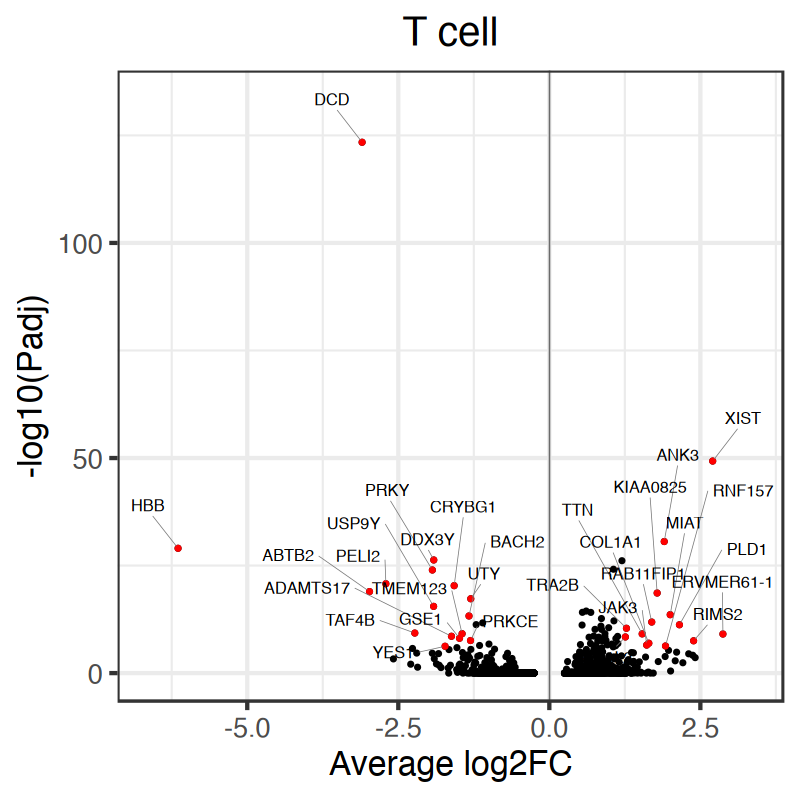

In [40]:
ct = 'T.cell'
tolabel = markers[[ct]] %>% filter(abs(avg_log2FC) > 1.25 & -log10(p_val_adj) > 6)

fig.size(4, 4)
p = volcano_plot(markers[[ct]], tolabel, title = 'T cell', nx = 0.5, ny = 10)
pdf(paste0('../_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_', ct, '.pdf'), width = 4, height = 4)
print(p); dev.off()
p

agg_record_16ff916bbcb65 
                       2

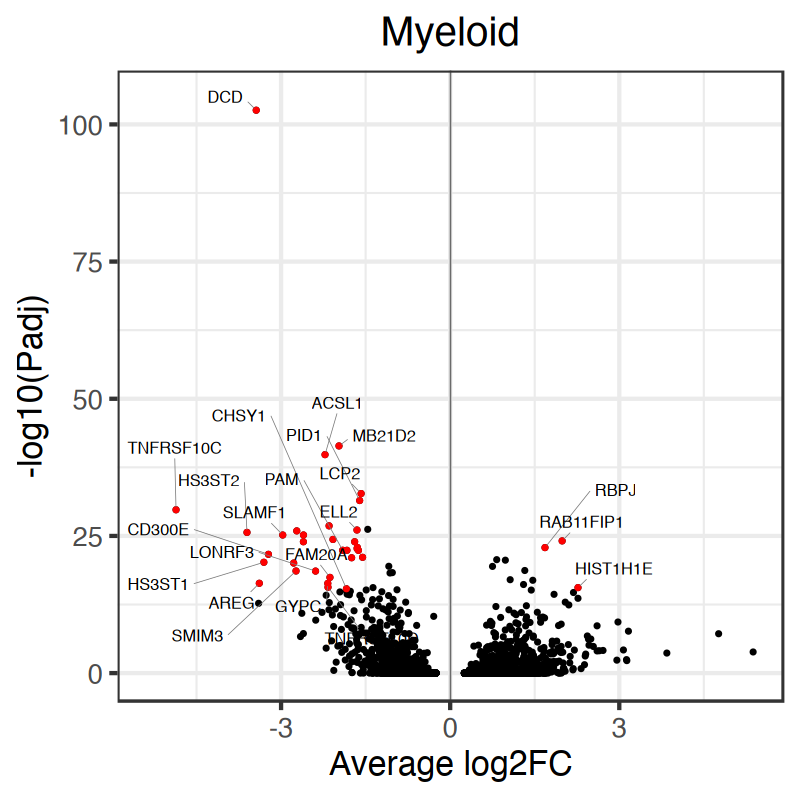

In [15]:
ct = 'Myeloid'
tolabel = markers[[ct]] %>% filter(abs(avg_log2FC) > 1.5 & -log10(p_val_adj) > 15)

fig.size(4, 4)
p = volcano_plot(markers[[ct]], tolabel, title = 'Myeloid', nx = 0.5, ny = 2)
pdf(paste0('../_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_', ct, '.pdf'), width = 4, height = 4)
print(p); dev.off()
p

agg_record_16ff9343350f 
                      2

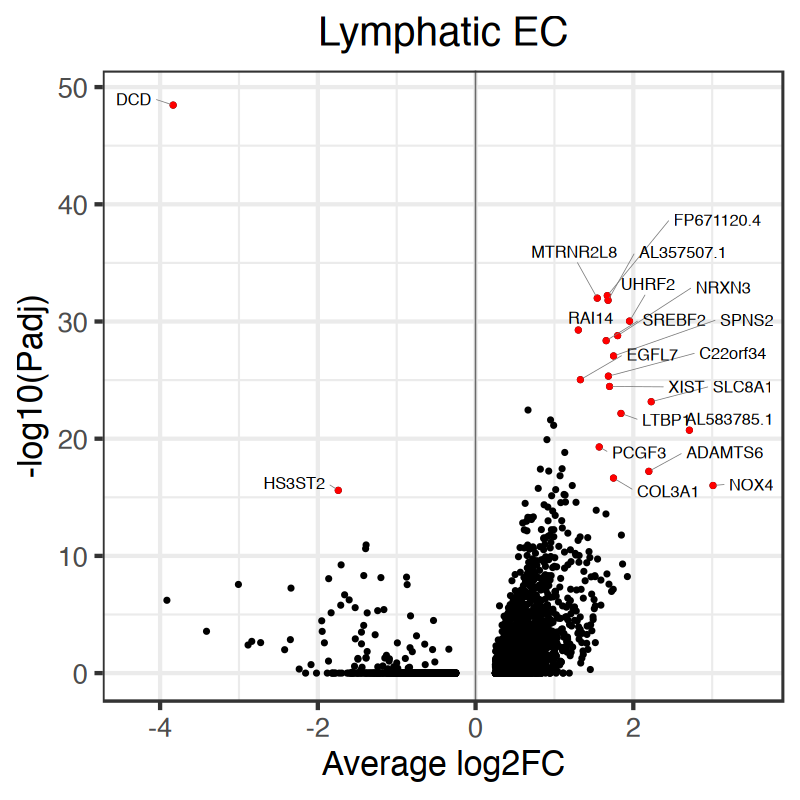

In [16]:
ct = 'Lymphatic.EC'
tolabel = markers[[ct]] %>% filter(abs(avg_log2FC) > 1.25 & -log10(p_val_adj) > 15)

fig.size(4, 4)
p = volcano_plot(markers[[ct]], tolabel, title = 'Lymphatic EC', nx = 0.5, ny = 0.5)
pdf(paste0('../_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_', ct, '.pdf'), width = 4, height = 4)
print(p); dev.off()
p

agg_record_16ff92ac11a0d 
                       2

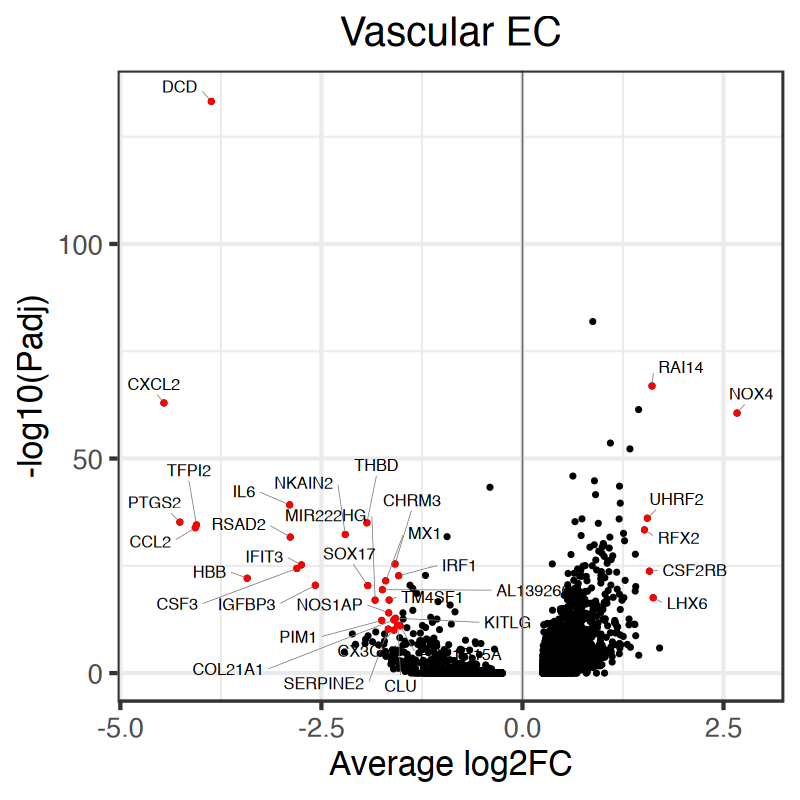

In [17]:
ct = 'Vascular.EC'
tolabel = markers[[ct]] %>% filter(abs(avg_log2FC) > 1.5 & -log10(p_val_adj) > 10)

fig.size(4, 4)
p = volcano_plot(markers[[ct]], tolabel, title = 'Vascular EC', nx = 0.2, ny = 0.5)
pdf(paste0('../_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_', ct, '.pdf'), width = 4, height = 4)
print(p); dev.off()
p

agg_record_16ff942ef5f6f 
                       2

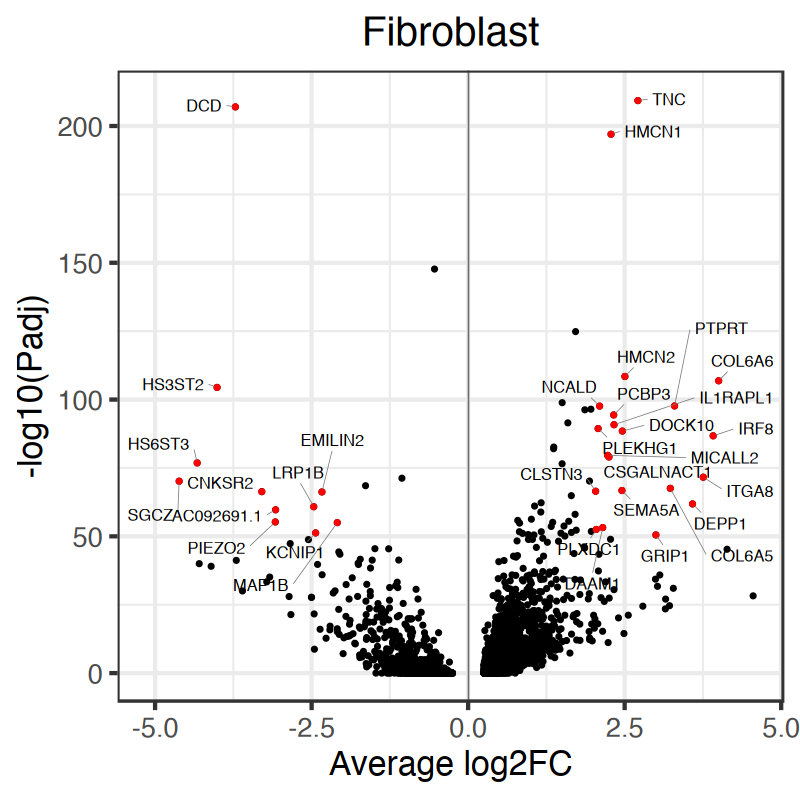

In [43]:
ct = 'Fibroblast'
tolabel = markers[[ct]] %>% filter(abs(avg_log2FC) > 2.0 & -log10(p_val_adj) > 50)

fig.size(4, 4)
p = volcano_plot(markers[[ct]], tolabel, title = 'Fibroblast', nx = 0.5, ny = 0.5)
pdf(paste0('../_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_', ct, '.pdf'), width = 4, height = 4)
print(p); dev.off()
p

agg_record_16ff92b9c2f8 
                      2

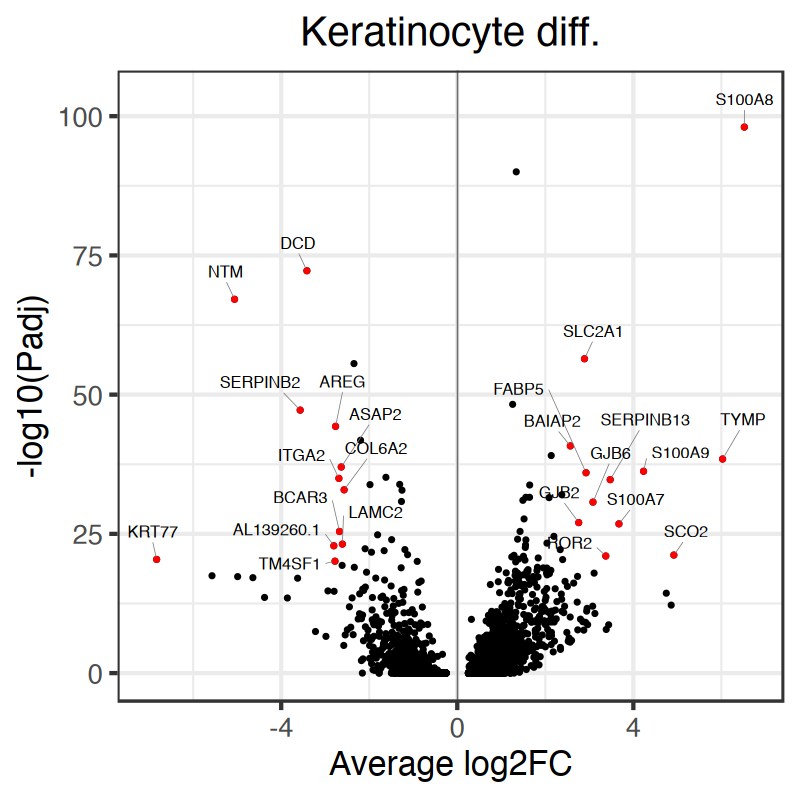

In [19]:
ct = 'Keratinocyte.diff.'
tolabel = markers[[ct]] %>% filter(abs(avg_log2FC) > 2.5 & -log10(p_val_adj) > 20)

fig.size(4, 4)
p = volcano_plot(markers[[ct]], tolabel, title = 'Keratinocyte diff.', nx = 0.2, ny = 5)
pdf(paste0('../_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_', ct, '.pdf'), width = 4, height = 4)
print(p); dev.off()
p

S100A8 and S100A9 is interesting (higher in lesional vs. NL)

agg_record_16ff939049c4 
                      2

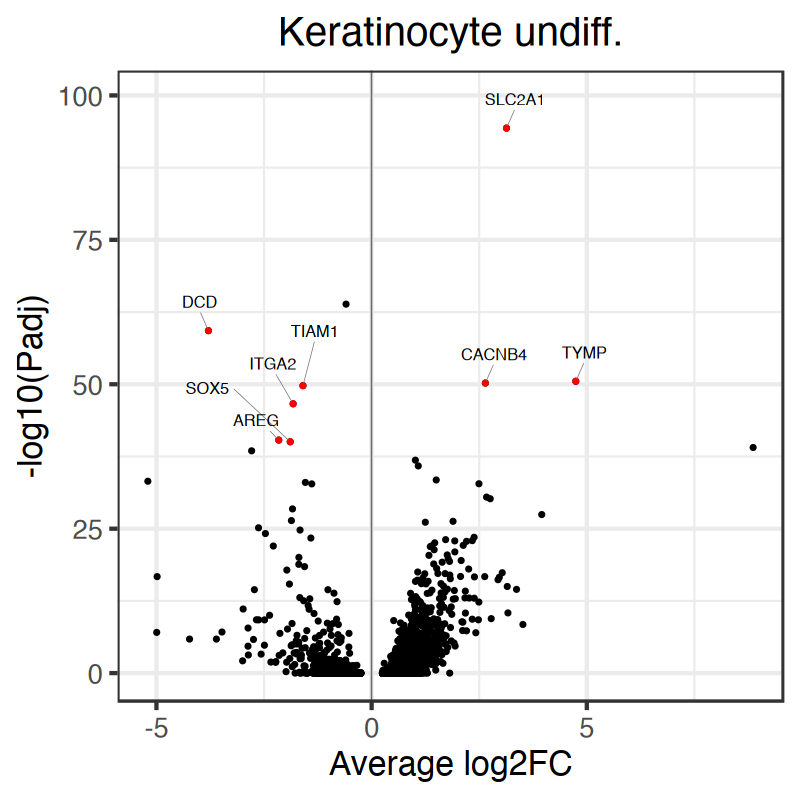

In [20]:
ct = 'Keratinocyte.undiff.'
tolabel = markers[[ct]] %>% filter(abs(avg_log2FC) > 1.5 & -log10(p_val_adj) > 40)

fig.size(4, 4)
p = volcano_plot(markers[[ct]], tolabel, title = 'Keratinocyte undiff.', nx = 0.2, ny = 5)
pdf(paste0('../_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_', ct, '.pdf'), width = 4, height = 4)
print(p); dev.off()
p

agg_record_16ff952ea4a1d 
                       2

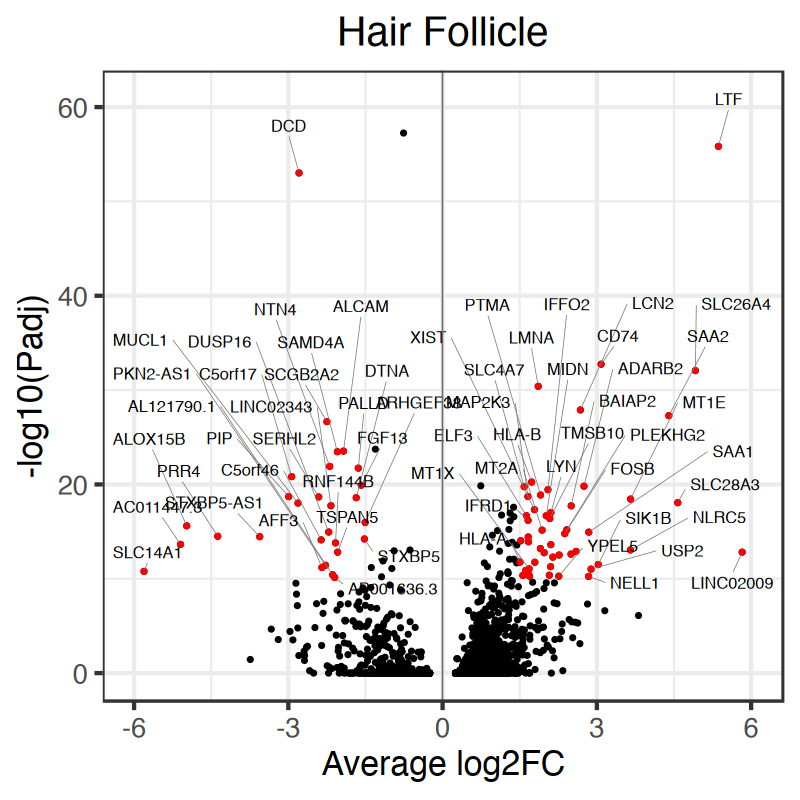

In [21]:
ct = 'Hair.follicle'
tolabel = markers[[ct]] %>% filter(abs(avg_log2FC) > 1.5 & -log10(p_val_adj) > 10)

fig.size(4, 4)
p = volcano_plot(markers[[ct]], tolabel, title = 'Hair Follicle', nx = 0.2, ny = 5)
pdf(paste0('../_figures/volcanos/snRNA_Wk0Untx_vs_Wk0NL_', ct, '.pdf'), width = 4, height = 4)
print(p); dev.off()
p

In [22]:
for (ct in unique(names(markers))) {
    markers_ct = markers[[ct]]
    write.csv(markers_ct, paste0(res_dir, '/Wk0Untx_vs_Wk0NL_', ct, '.csv'))
}

## Violin plots - Pattern across subjects

In [23]:
CustomVlnPlot <- function(seurat_obj, features, group.by = "ident", color.by= 'Type',
                         type_col = "Type", pt.size = 0, combine = TRUE, 
                         cols = c('#8ee6ad', '#ed8866'), y.max = NULL) {
    
    # Extract data for plotting
    plot_data <- FetchData(seurat_obj, 
                          vars = c(features, group.by, type_col)) %>% gather(key = "Feature", value = "Expression", -all_of(c(group.by, type_col)))
    
    # Calculate statistics for violin plot
    stats_data <- plot_data %>%
        group_by(!!sym(group.by), !!sym(type_col), Feature) %>%
        summarise(
            median = median(Expression),
            mean = mean(Expression),
            q25 = quantile(Expression, 0.25),
            q75 = quantile(Expression, 0.75))
    
    # Create plot
    plots <- lapply(features, function(feature) {
        p <- ggplot(plot_data %>% filter(Feature == feature), 
                   aes(x = !!sym(group.by), 
                       y = Expression, 
                       fill = !!sym(color.by))) +
            geom_violin(scale = "width", adjust = 1, trim = TRUE, linewidth = 0.2) +
            geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA, linewidth = 0.2) +
            facet_grid(~Type, scales = "free_x", space = "free") +  # Add faceting
            theme_bw(base_size = 11) +
            theme(
                axis.text.x = element_text(angle = 45, hjust = 1, size = 11),
                legend.position = "none",
                panel.grid.major.x = element_blank(),
                panel.grid.minor.x = element_blank()) +
            labs(title = feature, x = NULL, y = "Expression Level") +
            theme(strip.text.x = element_text(size = 11))
        
        # Add points if requested
        if(pt.size > 0) {
            p <- p + geom_jitter(size = pt.size, alpha = 0.2, width = 0.2)
        }
        
        ## Add custom colors if provided
        if(!is.null(cols)) {
            p <- p + scale_fill_manual(values = cols)
        }
        
        # Set y axis limit if provided
        if(!is.null(y.max)) {
            p <- p + coord_cartesian(ylim = c(0, y.max))
        }
        return(p)
    })
    
    # Combine plots if requested
    if(combine && length(features) > 1) {
        return(wrap_plots(plots, ncol = min(length(features), 2)))
    } else {
        return(plots)
    }
}

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by PatientID, Type, and Feature.
ℹ Output is grouped by PatientID and Type.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(PatientID, Type, Feature))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


agg_record_16ff95b561308 
                       2

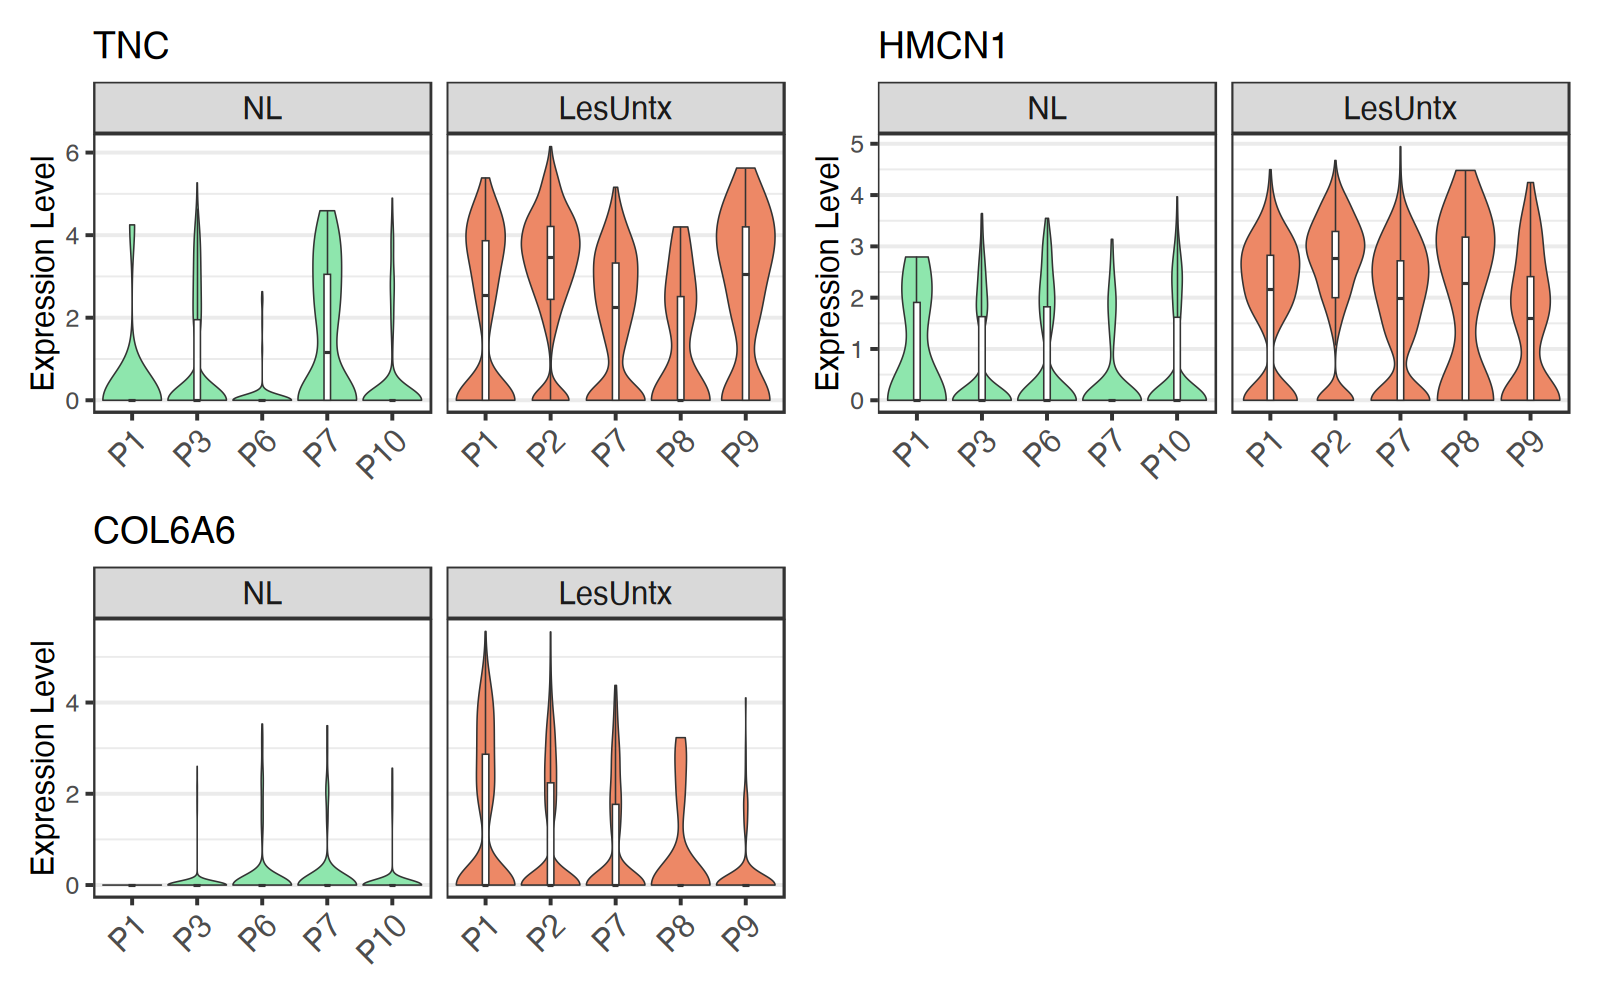

In [24]:
fig.size(5, 8)
obj_F = subset(obj_snRNA_Wk0, subset = cell_type == 'Fibroblast')
p = CustomVlnPlot(obj_F, 
             features = c('TNC', 'HMCN1', 'COL6A6'), 
             group.by = "PatientID",
             type_col = "Type") 
pdf('../_figures/violins_untx/Fibroblast_UntxVsNL_selected_genes.pdf', width = 8, height = 5)
print(p)
dev.off()
p

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Subject, Type, and Feature.
ℹ Output is grouped by Subject and Type.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Subject, Type, Feature))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


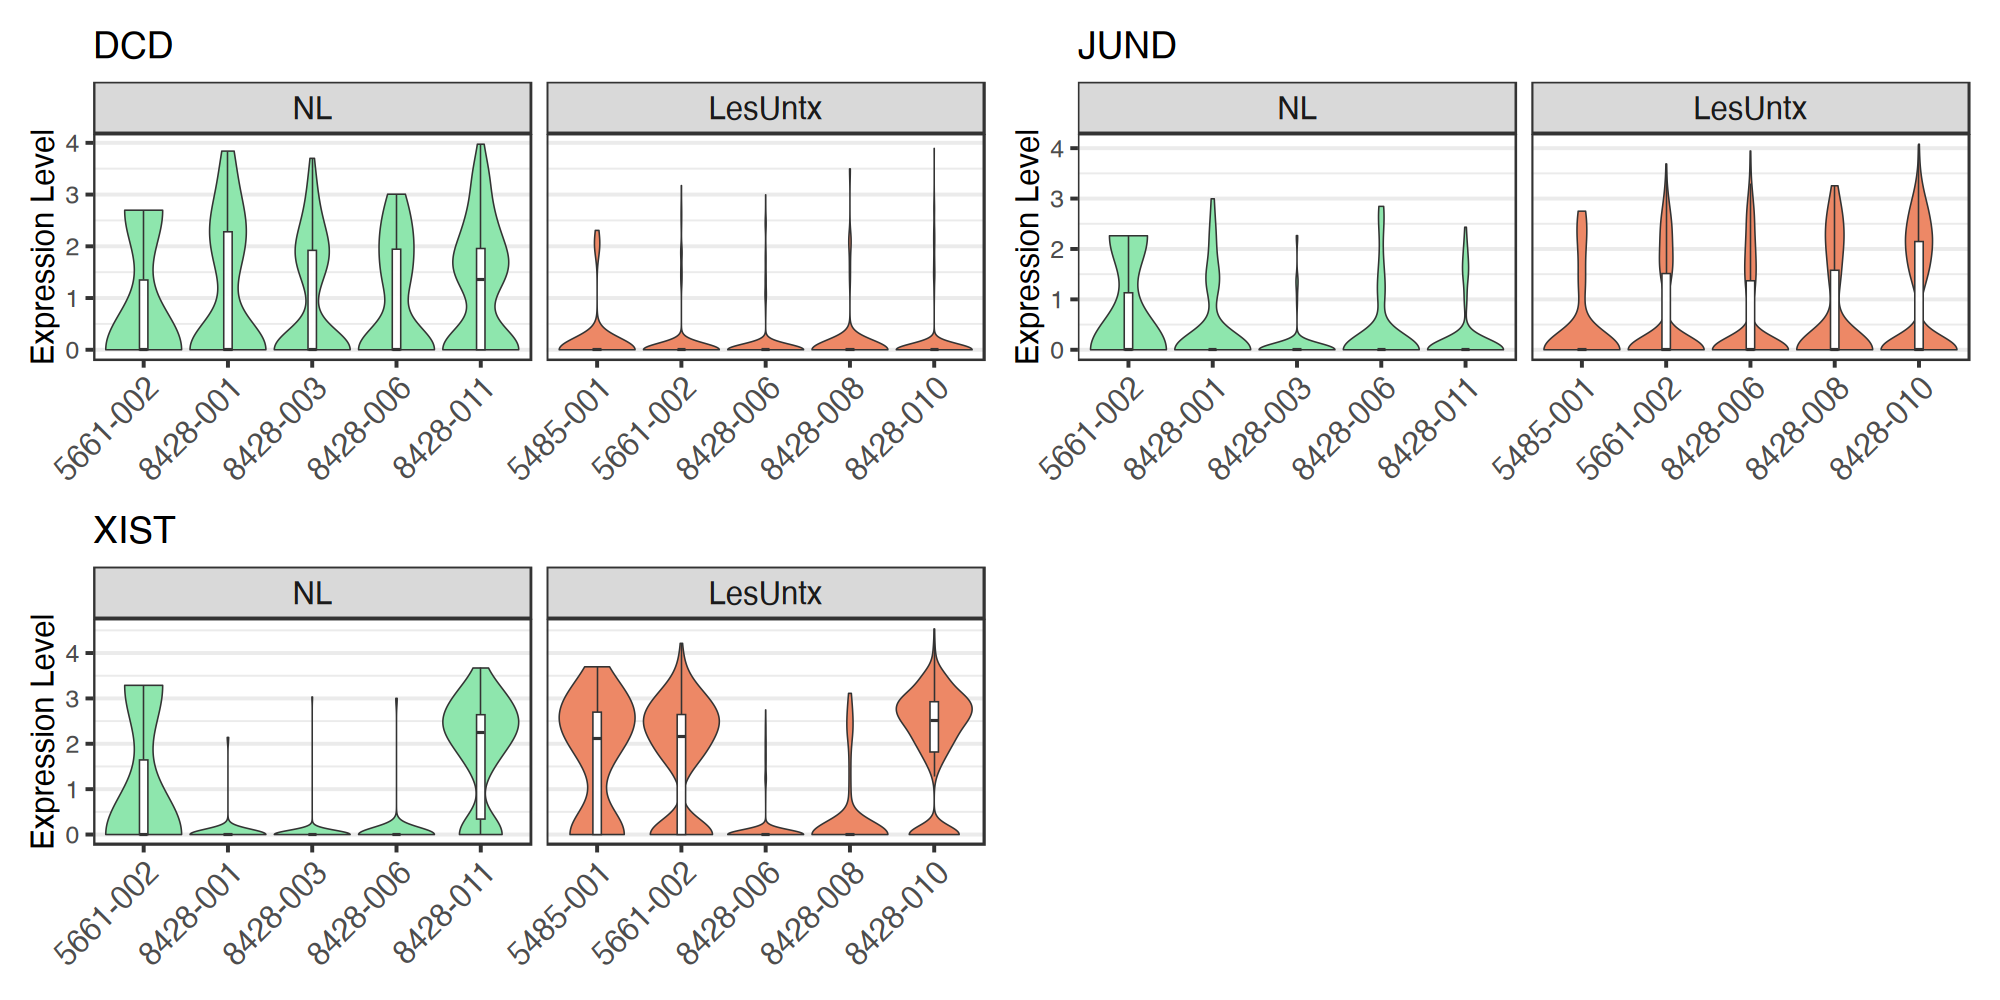

In [25]:
fig.size(5, 10)
obj_M = subset(obj_snRNA_Wk0, subset = cell_type == 'Myeloid')
CustomVlnPlot(obj_M, 
             features = c('DCD', 'JUND', 'XIST'), 
             group.by = "Subject",
             type_col = "Type")  # specify your Type column name

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Subject, Type, and Feature.
ℹ Output is grouped by Subject and Type.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Subject, Type, Feature))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


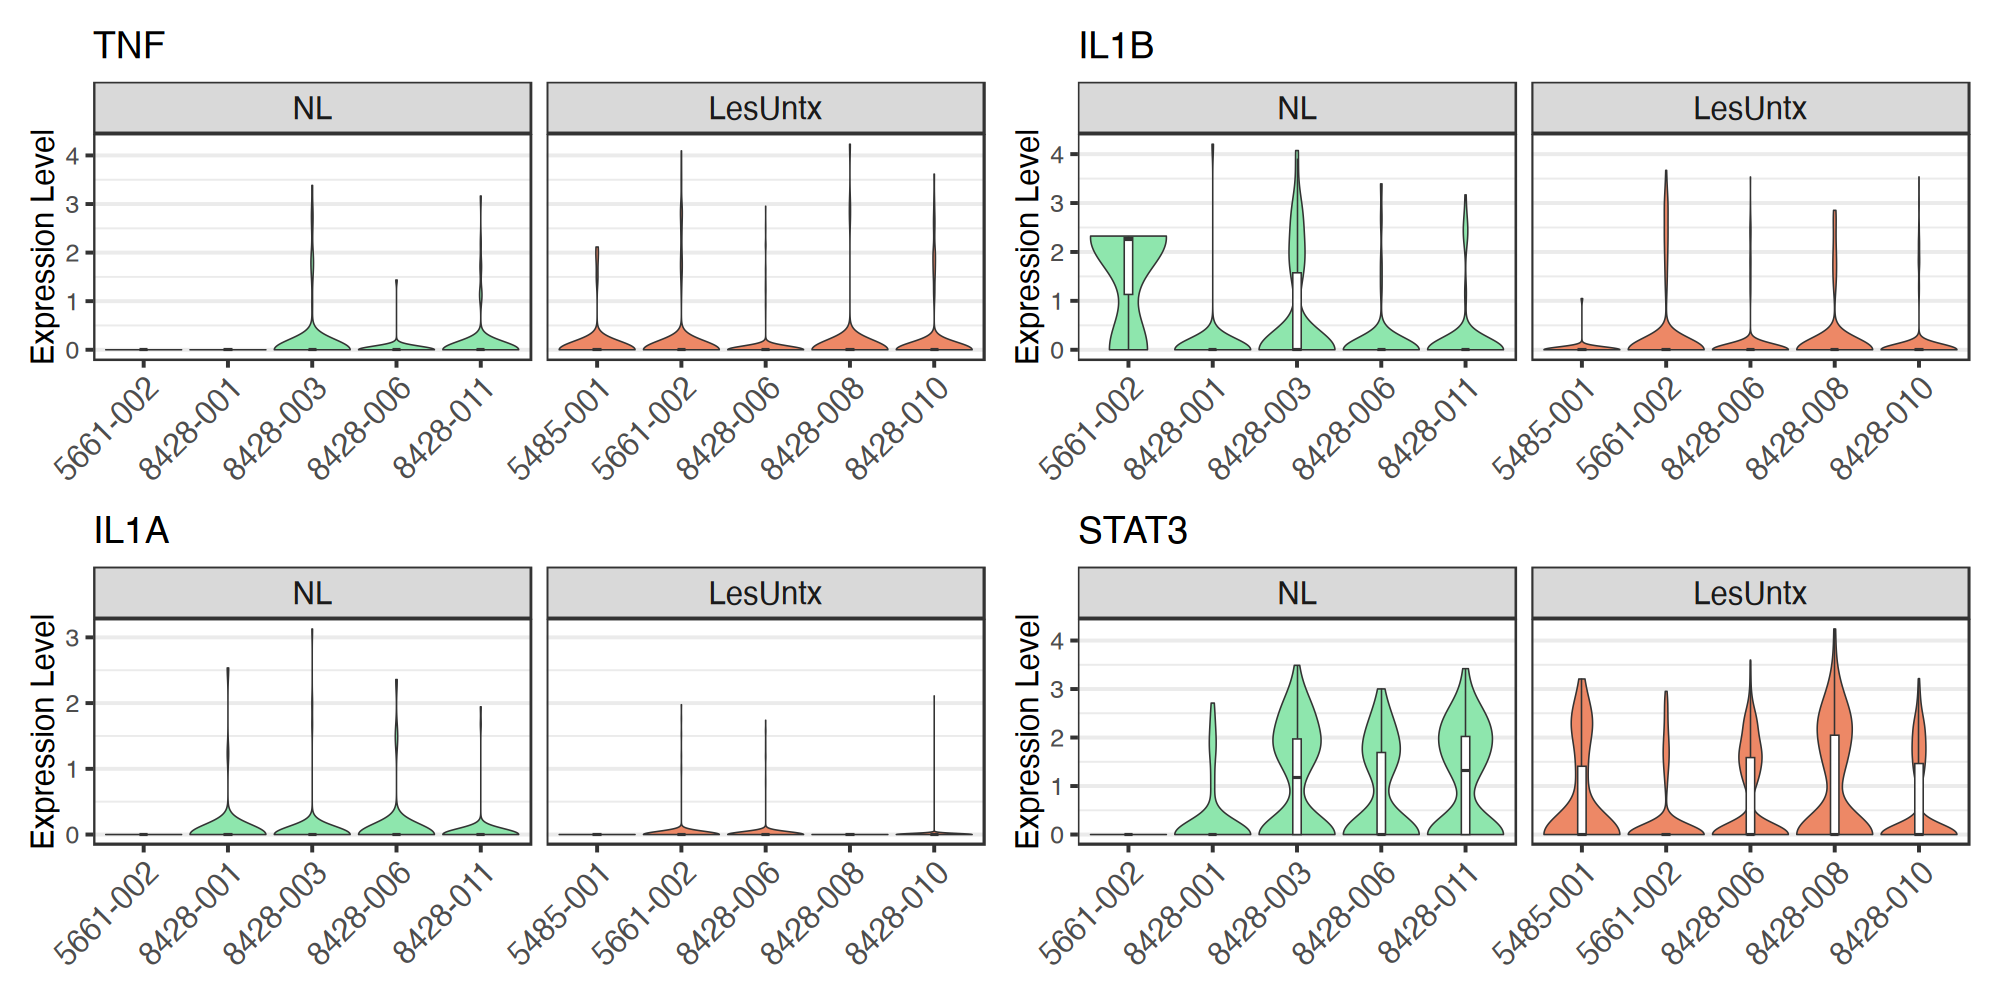

In [26]:
fig.size(5, 10)
obj_M = subset(obj_snRNA_Wk0, subset = cell_type == 'Myeloid')
CustomVlnPlot(obj_M, 
             features = c('TNF', "IL1B", "IL1A", "STAT3"), 
             group.by = "Subject",
             type_col = "Type")  # specify your Type column name

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by PatientID, Type, and Feature.
ℹ Output is grouped by PatientID and Type.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(PatientID, Type, Feature))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


agg_record_16ff958bf7c7a 
                       2

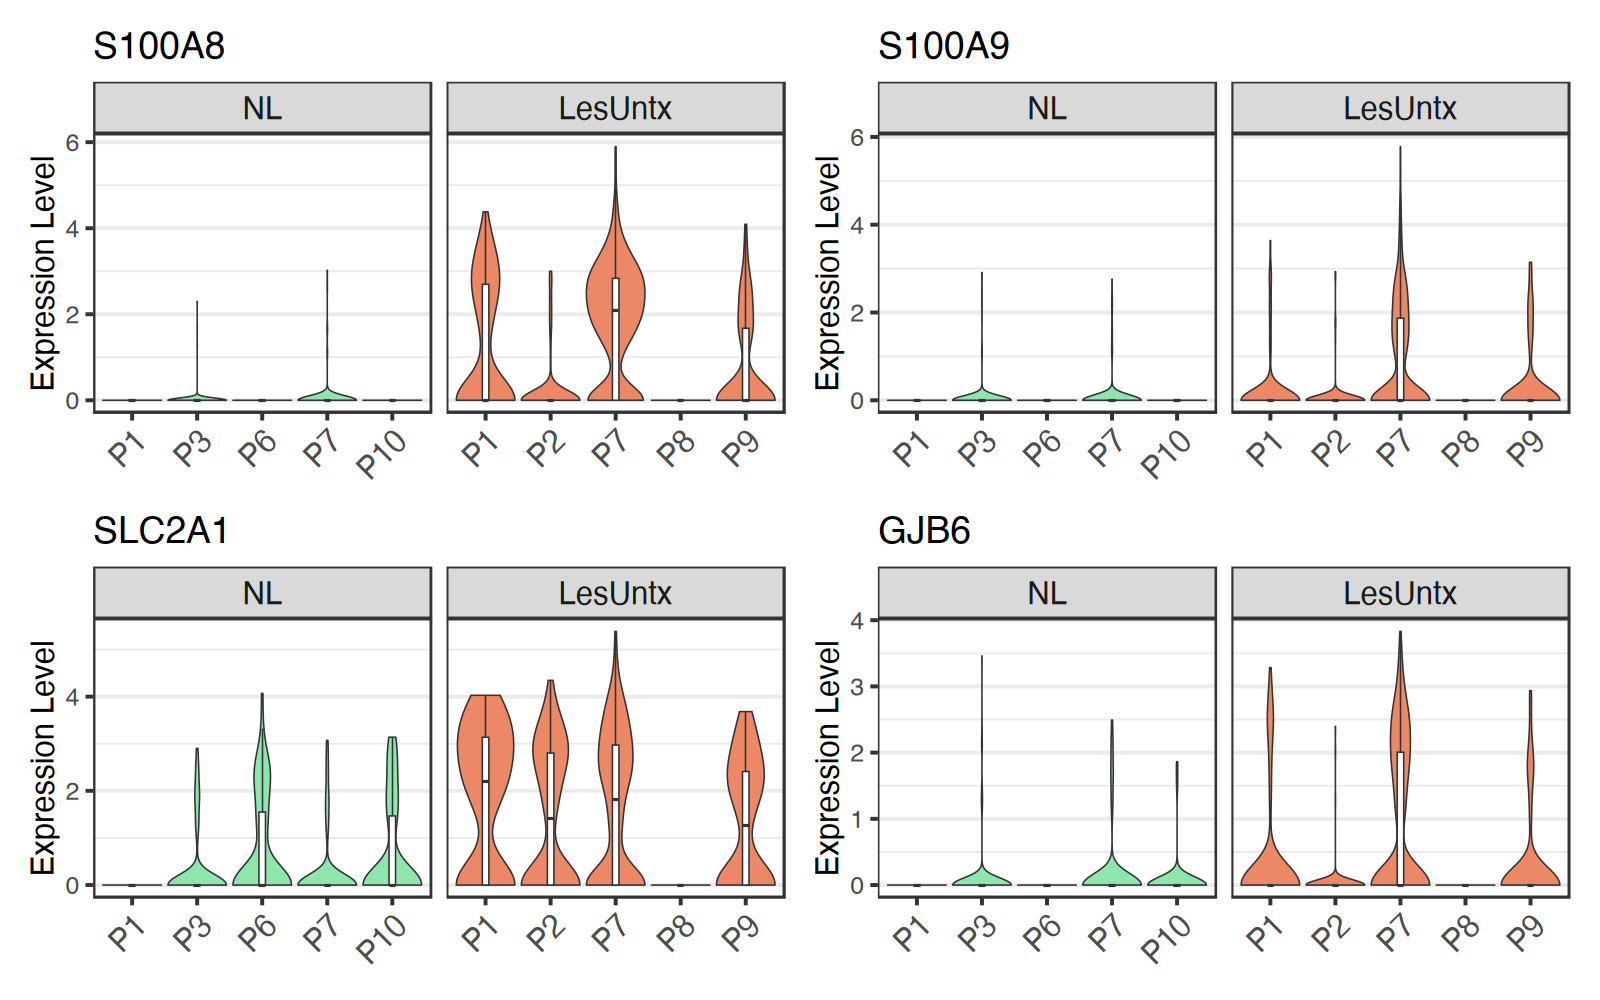

In [27]:
fig.size(5, 8)
obj_K = subset(obj_snRNA_Wk0, subset = cell_type == 'Keratinocyte.diff.')
p = CustomVlnPlot(obj_K, 
             features = c('S100A8', "S100A9", "SLC2A1", "GJB6"), 
             group.by = "PatientID",
             type_col = "Type")  # specify your Type column name
pdf('../_figures/violins_untx/Keratinocyte.diff_UntxVsNL_selected_genes.pdf', width = 8, height = 5)
print(p)
dev.off()
p

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by PatientID, Type, and Feature.
ℹ Output is grouped by PatientID and Type.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(PatientID, Type, Feature))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


agg_record_16ff93be3c735 
                       2

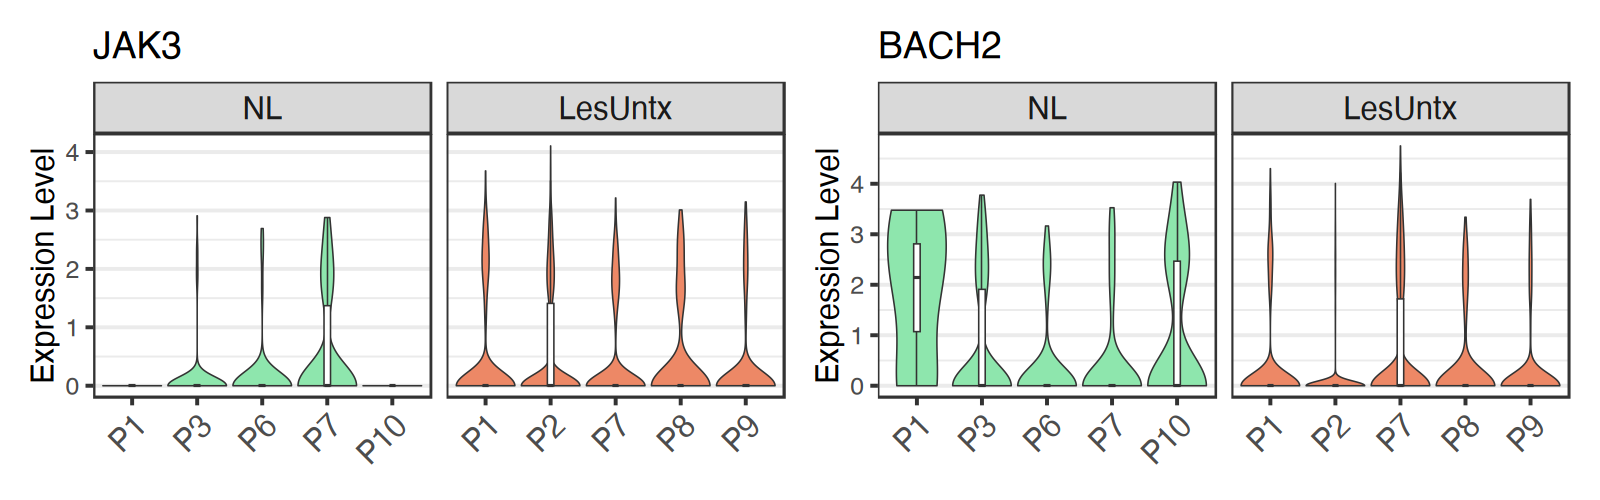

In [28]:
fig.size(2.5, 8)
obj_T = subset(obj_snRNA_Wk0, subset = cell_type == 'T.cell')
p = CustomVlnPlot(obj_T, 
             features = c('JAK3', 'BACH2'), 
             group.by = "PatientID",
             type_col = "Type")  # specify your Type column name
pdf('../_figures/violins_untx/T_UntxVsNL_selected_genes.pdf', width = 8, height = 2.5)
print(p)
dev.off()
p

# GSEA

In [29]:
Wk0UntxvsW0NL = readRDS('../_results/SeuratFindMarkers_Untx/markers_Wk0Untx_vs_Wk0NL.rds')

In [30]:
gene_sets = load_gene_sets()
hallmark_gene_sets = gene_sets$hallmark
all_gene_sets = gene_sets$all

unique(all_gene_sets$gs_name) %>% length()
unique(hallmark_gene_sets$gs_name) %>% length()

[1] 7774

[1] 50

In [31]:
set.seed(1)
suppressMessages({ suppressWarnings({
    # run_GSEA_on_list is defined in utils.R
run_GSEA_on_list(Wk0UntxvsW0NL, out_dir = "../_results/GSEA_Untx_vs_NL/hallmark_gs", label = "Wk0Untx_vs_Wk0NL", gene_set = hallmark_gene_sets, plot_width = 12)
run_GSEA_on_list(Wk0UntxvsW0NL, out_dir = "../_results/GSEA_Untx_vs_NL/all_gs",      label = "Wk0Untx_vs_Wk0NL", gene_set = all_gene_sets,      plot_width = 12)
}) })

# Write DE results to .csv files for IPA

In [32]:
save_to_csvs(Wk0UntxvsW0NL, out_dir = '../_results/SeuratDEFormatforIPA/LesUntx_vs_NL_Wk0')

In [33]:
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: aarch64-apple-darwin20.0.0
Running under: macOS Sonoma 14.6

Matrix products: default
BLAS/LAPACK: /opt/anaconda3/envs/resiq/lib/libopenblas.0.dylib;  LAPACK version 3.12.0

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

time zone: America/New_York
tzcode source: system (macOS)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] org.Hs.eg.db_3.20.0         AnnotationDbi_1.68.0       
 [3] msigdbr_26.1.0              clusterProfiler_4.14.0     
 [5] rlang_1.2.0                 scales_1.4.0               
 [7] patchwork_1.3.2             RColorBrewer_1.1-3         
 [9] rstatix_0.7.3               mixtools_2.0.0.1           
[11] limma_3.62.2                cowplot_1.2.0              
[13] ggrastr_1.0.2               ggpubr_0.6.3               
[15] lme4_2.0-1                  singlecellmethods_0.1.0    
[17] MAST_1.32.0           